In [71]:
# Linear Algegra
import numpy as np
from scipy.stats import gmean, hmean
from scipy import stats

# Data Frame
import pandas as pd

# Data Visualisation
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Model Building
import sklearn.cluster 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, RobustScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import RidgeCV, LassoCV, LinearRegression
from sklearn.model_selection import train_test_split, KFold, GroupKFold, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeRegressor

from catboost import CatBoostRegressor  # Import CatBoostRegressor
from xgboost import XGBRegressor  # Import XGBRegressor
from lightgbm import LGBMRegressor  # Import LGBMRegressor

import h2o
from h2o.automl import H2OAutoML

from itertools import combinations

import os

# Supress Warnings
import warnings
warnings.filterwarnings("ignore", category=Warning)

# Display Settings
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('display.max_colwidth', 200)

# Set seed for reproducibility
seed = 42

In [29]:
# Define RMSE function
def rmse(y_true, y_pred):
    """
    Calculate Root Mean Squared Error (RMSE).

    Parameters:
        y_true (array-like): Array of true target values.
        y_pred (array-like): Array of predicted target values.

    Returns:
        float: Root Mean Squared Error.
    """
    return np.sqrt(mean_squared_error(y_true, y_pred))


In [30]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
soln = pd.read_csv("solution_template.csv")

# Data Preprocessing

In [31]:
#Combine train and test
test['metastatic_diagnosis_period'] = -1
combine = pd.concat([train, test], axis=0, ignore_index=True)
combine['source'] = np.where(combine['metastatic_diagnosis_period'] == -1, 'test', 'train')

In [32]:
combine[['patient_id', 'patient_gender', 'male', 'female']].head(8)

,patient_id,patient_gender,male,female
0,268700,F,51.43,48.57
1,484983,F,49.32,50.68
2,277055,F,49.99,50.01
3,320055,F,50.51,49.49
4,190386,F,51.99,48.01
5,559027,F,50.98,49.02
6,293747,F,49.91,50.09
7,517596,F,47.82,52.18


## Handling Noise & Inconsistent Data

In [33]:
#Fixing state, division and zip3 mapping according to Wikipedia
combine['patient_state'] = np.where(combine['patient_zip3'] == 630, 'MO', np.where(combine['patient_zip3'] == 864, 'AZ', combine['patient_state']))
combine['Division'] = np.where(combine['patient_state'] == 'MO', 'West North Central', combine['patient_state'])


In [34]:
#Fix diagnosis codes
combine['breast_cancer_diagnosis_code'] = combine['breast_cancer_diagnosis_code'].replace({
    #Change male to female
    'C50122': 'C50112', 'C50221': 'C50211', 'C50421': 'C50411', 'C50922': 'C50912',
    #Recode categories
    'C509': 'C5091',
    #Convert ICD-9 to ICD-10
    '1741': 'C50119', '1742': 'C50219', '1743': 'C50319', '1744': 'C50419', '1745': 'C50519',
    '1746': 'C50619', '1748': 'C50819', '1749': 'C50919', '19881': 'C7981', '1759': 'C50929'
})

In [35]:
pop_col = combine.loc[:, 'population':'veteran'].columns.to_list()

#Fix valuesfor patient_zip3==395
combine.loc[combine.patient_id == 714510, pop_col] = combine.loc[combine.patient_id == 636245, pop_col].values

#Fix values for patient_zip3==968
combine.loc[combine.patient_id == 271422, pop_col] = combine.loc[combine.patient_id == 271245, pop_col].values

#Fix values for patient_zip3==988
combine.loc[combine.patient_id == 441322, pop_col] = combine.loc[combine.patient_id == 982003, pop_col].values


## Cleaning NaN Values

In [36]:
combine.isna().sum()

patient_id                                   0
patient_race                              9442
payer_type                                2550
patient_state                                0
patient_zip3                                 0
Region                                       0
Division                                     0
patient_age                                  0
patient_gender                               0
bmi                                      13012
breast_cancer_diagnosis_code                 0
breast_cancer_diagnosis_desc                 0
metastatic_cancer_diagnosis_code             0
metastatic_first_novel_treatment         18801
metastatic_first_novel_treatment_type    18801
population                                   0
density                                      0
age_median                                   0
age_under_10                                 0
age_10_to_19                                 0
age_20s                                      0
age_30s      

In [37]:
#Subset dataframe for temperature variables
temp_col = combine.columns[combine.columns.str.startswith('Average')].tolist()
df_temp = combine[['patient_zip3', 'patient_state'] + temp_col].drop_duplicates().sort_values(by='patient_zip3').reset_index(drop=True)

print(df_temp.shape)
df_temp.head()

(763, 74)


,patient_zip3,patient_state,Average of Jan-13,Average of Feb-13,Average of Mar-13,Average of Apr-13,Average of May-13,Average of Jun-13,Average of Jul-13,Average of Aug-13,Average of Sep-13,Average of Oct-13,Average of Nov-13,Average of Dec-13,Average of Jan-14,Average of Feb-14,Average of Mar-14,Average of Apr-14,Average of May-14,Average of Jun-14,Average of Jul-14,Average of Aug-14,Average of Sep-14,Average of Oct-14,Average of Nov-14,Average of Dec-14,Average of Jan-15,Average of Feb-15,Average of Mar-15,Average of Apr-15,Average of May-15,Average of Jun-15,Average of Jul-15,Average of Aug-15,Average of Sep-15,Average of Oct-15,Average of Nov-15,Average of Dec-15,Average of Jan-16,Average of Feb-16,Average of Mar-16,Average of Apr-16,Average of May-16,Average of Jun-16,Average of Jul-16,Average of Aug-16,Average of Sep-16,Average of Oct-16,Average of Nov-16,Average of Dec-16,Average of Jan-17,Average of Feb-17,Average of Mar-17,Average of Apr-17,Average of May-17,Average of Jun-17,Average of Jul-17,Average of Aug-17,Average of Sep-17,Average of Oct-17,Average of Nov-17,Average of Dec-17,Average of Jan-18,Average of Feb-18,Average of Mar-18,Average of Apr-18,Average of May-18,Average of Jun-18,Average of Jul-18,Average of Aug-18,Average of Sep-18,Average of Oct-18,Average of Nov-18,Average of Dec-18
0,100,NY,33.44,30.84,38.45,51.26,60.18,71.91,78.55,71.32,64.49,56.13,41.99,34.79,24.37,26.97,33.92,49.99,61.76,70.54,74.73,71.48,66.73,55.69,41.66,38.25,26.53,20.84,34.33,50.51,66.72,69.80,75.96,75.25,71.07,54.58,48.87,46.33,30.06,35.06,46.52,51.23,60.48,72.47,77.11,77.54,70.08,56.80,45.79,35.42,35.37,37.89,37.02,56.56,59.65,71.17,76.11,72.17,69.26,60.80,42.89,32.62,27.67,37.57,37.87,47.55,65.06,70.23,77.12,77.72,69.82,55.79,42.04,37.18
1,101,NY,33.51,30.81,38.44,51.27,60.14,71.98,78.64,71.34,64.53,56.15,42.03,34.93,24.42,26.97,33.92,NaN,61.76,NaN,74.75,71.51,66.77,55.65,41.72,38.32,26.62,20.97,34.39,50.56,66.82,69.84,76.02,75.35,71.20,54.72,48.96,46.43,30.09,35.16,46.64,51.34,60.55,72.67,77.19,77.67,70.22,56.95,45.83,35.54,35.45,37.99,37.09,56.75,59.79,71.37,76.24,72.29,69.38,60.93,43.01,32.70,27.77,37.69,37.95,47.68,65.17,70.33,77.22,77.83,69.93,55.92,42.16,37.26
2,103,NY,34.01,31.87,38.52,51.63,60.29,71.92,78.43,71.46,64.39,56.21,42.56,35.83,25.57,26.97,34.67,51.46,61.74,70.47,74.70,71.37,66.91,56.54,41.69,38.68,27.28,21.76,35.17,50.75,66.20,69.40,75.87,75.20,70.58,54.21,48.93,47.42,30.88,35.79,46.99,51.55,60.28,71.85,77.05,77.30,70.17,56.61,46.67,36.33,36.01,39.22,37.09,56.44,59.80,70.75,76.06,72.15,69.15,60.29,43.77,32.91,28.04,38.68,38.14,47.99,65.17,70.81,76.90,77.75,69.90,56.45,42.55,37.49
3,104,NY,32.81,31.04,38.55,51.15,60.48,71.39,77.86,71.19,64.10,55.98,41.73,33.68,23.95,26.97,33.92,49.99,61.76,70.54,74.55,71.22,66.44,56.05,41.21,37.70,25.83,19.78,33.79,50.08,65.92,69.54,75.48,74.45,70.01,53.43,48.15,45.55,29.80,34.24,45.55,50.29,59.92,70.84,76.48,76.47,68.93,55.55,45.48,34.50,34.72,37.03,36.50,55.00,58.52,69.56,75.05,71.20,68.33,59.81,41.91,31.91,26.81,36.58,37.22,46.54,64.18,69.41,76.37,76.81,68.91,54.75,41.06,36.54
4,105,NY,29.13,27.78,34.54,48.12,58.59,67.86,75.06,68.19,61.44,53.31,38.38,31.92,20.03,20.35,28.98,46.86,59.60,67.73,72.00,68.59,64.27,54.66,38.04,34.64,22.47,15.58,30.56,47.75,63.83,66.95,72.20,71.25,67.61,50.64,45.29,42.99,26.84,31.00,42.83,47.79,57.43,67.18,73.73,73.14,66.10,52.98,43.58,32.09,31.65,34.71,33.61,52.17,56.50,66.72,71.75,68.49,65.46,57.39,40.07,28.83,23.77,33.59,34.47,43.69,62.71,66.81,73.70,73.99,66.41,52.29,38.51,33.56


In [38]:
#Melt temperature dataframe
df_temp = pd.melt(df_temp, id_vars=['patient_zip3', 'patient_state'])

#Convert month to datetime format
df_temp['month'] = df_temp['variable'].apply(lambda x: x[len(x)-6:])
df_temp['month'] = pd.to_datetime(df_temp['month'], format='%b-%y')

#Sort time wise by location
df_temp.sort_values(by=['patient_zip3', 'patient_state', 'month'], inplace=True)

#Imputation method: forward fill, then backward fill for remaining
df_temp['value'] = df_temp.groupby(['patient_zip3', 'patient_state'])['value'].ffill()
df_temp['value'] = df_temp.groupby(['patient_zip3', 'patient_state'])['value'].bfill()
df_temp.head()

,patient_zip3,patient_state,variable,value,month
0,100,NY,Average of Jan-13,33.44,2013-01-01
763,100,NY,Average of Feb-13,30.84,2013-02-01
1526,100,NY,Average of Mar-13,38.45,2013-03-01
2289,100,NY,Average of Apr-13,51.26,2013-04-01
3052,100,NY,Average of May-13,60.18,2013-05-01


In [39]:
#Bring data to initial format
df_temp = df_temp.drop('month', axis=1).pivot(index=['patient_zip3', 'patient_state'],columns='variable', values='value').reset_index()[['patient_zip3', 'patient_state'] + temp_col]
print(df_temp.shape)
df_temp.head()

(763, 74)


variable,patient_zip3,patient_state,Average of Jan-13,Average of Feb-13,Average of Mar-13,Average of Apr-13,Average of May-13,Average of Jun-13,Average of Jul-13,Average of Aug-13,Average of Sep-13,Average of Oct-13,Average of Nov-13,Average of Dec-13,Average of Jan-14,Average of Feb-14,Average of Mar-14,Average of Apr-14,Average of May-14,Average of Jun-14,Average of Jul-14,Average of Aug-14,Average of Sep-14,Average of Oct-14,Average of Nov-14,Average of Dec-14,Average of Jan-15,Average of Feb-15,Average of Mar-15,Average of Apr-15,Average of May-15,Average of Jun-15,Average of Jul-15,Average of Aug-15,Average of Sep-15,Average of Oct-15,Average of Nov-15,Average of Dec-15,Average of Jan-16,Average of Feb-16,Average of Mar-16,Average of Apr-16,Average of May-16,Average of Jun-16,Average of Jul-16,Average of Aug-16,Average of Sep-16,Average of Oct-16,Average of Nov-16,Average of Dec-16,Average of Jan-17,Average of Feb-17,Average of Mar-17,Average of Apr-17,Average of May-17,Average of Jun-17,Average of Jul-17,Average of Aug-17,Average of Sep-17,Average of Oct-17,Average of Nov-17,Average of Dec-17,Average of Jan-18,Average of Feb-18,Average of Mar-18,Average of Apr-18,Average of May-18,Average of Jun-18,Average of Jul-18,Average of Aug-18,Average of Sep-18,Average of Oct-18,Average of Nov-18,Average of Dec-18
0,100,NY,33.44,30.84,38.45,51.26,60.18,71.91,78.55,71.32,64.49,56.13,41.99,34.79,24.37,26.97,33.92,49.99,61.76,70.54,74.73,71.48,66.73,55.69,41.66,38.25,26.53,20.84,34.33,50.51,66.72,69.80,75.96,75.25,71.07,54.58,48.87,46.33,30.06,35.06,46.52,51.23,60.48,72.47,77.11,77.54,70.08,56.80,45.79,35.42,35.37,37.89,37.02,56.56,59.65,71.17,76.11,72.17,69.26,60.80,42.89,32.62,27.67,37.57,37.87,47.55,65.06,70.23,77.12,77.72,69.82,55.79,42.04,37.18
1,101,NY,33.51,30.81,38.44,51.27,60.14,71.98,78.64,71.34,64.53,56.15,42.03,34.93,24.42,26.97,33.92,33.92,61.76,61.76,74.75,71.51,66.77,55.65,41.72,38.32,26.62,20.97,34.39,50.56,66.82,69.84,76.02,75.35,71.20,54.72,48.96,46.43,30.09,35.16,46.64,51.34,60.55,72.67,77.19,77.67,70.22,56.95,45.83,35.54,35.45,37.99,37.09,56.75,59.79,71.37,76.24,72.29,69.38,60.93,43.01,32.70,27.77,37.69,37.95,47.68,65.17,70.33,77.22,77.83,69.93,55.92,42.16,37.26
2,103,NY,34.01,31.87,38.52,51.63,60.29,71.92,78.43,71.46,64.39,56.21,42.56,35.83,25.57,26.97,34.67,51.46,61.74,70.47,74.70,71.37,66.91,56.54,41.69,38.68,27.28,21.76,35.17,50.75,66.20,69.40,75.87,75.20,70.58,54.21,48.93,47.42,30.88,35.79,46.99,51.55,60.28,71.85,77.05,77.30,70.17,56.61,46.67,36.33,36.01,39.22,37.09,56.44,59.80,70.75,76.06,72.15,69.15,60.29,43.77,32.91,28.04,38.68,38.14,47.99,65.17,70.81,76.90,77.75,69.90,56.45,42.55,37.49
3,104,NY,32.81,31.04,38.55,51.15,60.48,71.39,77.86,71.19,64.10,55.98,41.73,33.68,23.95,26.97,33.92,49.99,61.76,70.54,74.55,71.22,66.44,56.05,41.21,37.70,25.83,19.78,33.79,50.08,65.92,69.54,75.48,74.45,70.01,53.43,48.15,45.55,29.80,34.24,45.55,50.29,59.92,70.84,76.48,76.47,68.93,55.55,45.48,34.50,34.72,37.03,36.50,55.00,58.52,69.56,75.05,71.20,68.33,59.81,41.91,31.91,26.81,36.58,37.22,46.54,64.18,69.41,76.37,76.81,68.91,54.75,41.06,36.54
4,105,NY,29.13,27.78,34.54,48.12,58.59,67.86,75.06,68.19,61.44,53.31,38.38,31.92,20.03,20.35,28.98,46.86,59.60,67.73,72.00,68.59,64.27,54.66,38.04,34.64,22.47,15.58,30.56,47.75,63.83,66.95,72.20,71.25,67.61,50.64,45.29,42.99,26.84,31.00,42.83,47.79,57.43,67.18,73.73,73.14,66.10,52.98,43.58,32.09,31.65,34.71,33.61,52.17,56.50,66.72,71.75,68.49,65.46,57.39,40.07,28.83,23.77,33.59,34.47,43.69,62.71,66.81,73.70,73.99,66.41,52.29,38.51,33.56


In [40]:
#Merge temperature data with combined dataframe
combine = combine.drop(temp_col, axis=1).merge(df_temp, how='left', on=['patient_zip3','patient_state'])
combine.insert(len(combine.columns)-1, 'metastatic_diagnosis_period', combine.pop('metastatic_diagnosis_period'))
combine.head()

,patient_id,patient_race,payer_type,patient_state,patient_zip3,Region,Division,patient_age,patient_gender,bmi,breast_cancer_diagnosis_code,breast_cancer_diagnosis_desc,metastatic_cancer_diagnosis_code,metastatic_first_novel_treatment,metastatic_first_novel_treatment_type,population,density,age_median,age_under_10,age_10_to_19,age_20s,age_30s,age_40s,age_50s,age_60s,age_70s,age_over_80,male,female,married,divorced,never_married,widowed,family_size,family_dual_income,income_household_median,income_household_under_5,income_household_5_to_10,income_household_10_to_15,income_household_15_to_20,income_household_20_to_25,income_household_25_to_35,income_household_35_to_50,income_household_50_to_75,income_household_75_to_100,income_household_100_to_150,income_household_150_over,income_household_six_figure,income_individual_median,home_ownership,housing_units,home_value,rent_median,rent_burden,education_less_highschool,education_highschool,education_some_college,education_bachelors,education_graduate,education_college_or_above,education_stem_degree,labor_force_participation,unemployment_rate,self_employed,farmer,race_white,race_black,race_asian,race_native,race_pacific,race_other,race_multiple,hispanic,disabled,poverty,limited_english,commute_time,health_uninsured,veteran,source,Average of Jan-13,Average of Feb-13,Average of Mar-13,Average of Apr-13,Average of May-13,Average of Jun-13,Average of Jul-13,Average of Aug-13,Average of Sep-13,Average of Oct-13,Average of Nov-13,Average of Dec-13,Average of Jan-14,Average of Feb-14,Average of Mar-14,Average of Apr-14,Average of May-14,Average of Jun-14,Average of Jul-14,Average of Aug-14,Average of Sep-14,Average of Oct-14,Average of Nov-14,Average of Dec-14,Average of Jan-15,Average of Feb-15,Average of Mar-15,Average of Apr-15,Average of May-15,Average of Jun-15,Average of Jul-15,Average of Aug-15,Average of Sep-15,Average of Oct-15,Average of Nov-15,Average of Dec-15,Average of Jan-16,Average of Feb-16,Average of Mar-16,Average of Apr-16,Average of May-16,Average of Jun-16,Average of Jul-16,Average of Aug-16,Average of Sep-16,Average of Oct-16,Average of Nov-16,Average of Dec-16,Average of Jan-17,Average of Feb-17,Average of Mar-17,Average of Apr-17,Average of May-17,Average of Jun-17,Average of Jul-17,Average of Aug-17,Average of Sep-17,Average of Oct-17,Average of Nov-17,Average of Dec-17,Average of Jan-18,Average of Feb-18,Average of Mar-18,Average of Apr-18,Average of May-18,Average of Jun-18,Average of Jul-18,Average of Aug-18,Average of Sep-18,Average of Oct-18,Average of Nov-18,Average of Dec-18,metastatic_diagnosis_period
0,268700,NaN,COMMERCIAL,AR,724,South,AR,39,F,NaN,C50912,Malignant neoplasm of unspecified site of left female breast,C773,NaN,NaN,3924.87,82.63,42.58,11.61,13.03,10.87,11.80,12.29,13.22,13.47,10.07,3.64,51.43,48.57,51.05,16.72,23.57,8.66,3.01,43.99,44483.35,2.21,3.97,8.52,7.08,7.67,13.82,15.14,17.51,11.26,8.90,3.93,12.83,24048.55,72.11,1513.75,87384.33,641.39,27.52,16.55,41.83,28.31,9.21,4.11,13.32,38.78,53.60,5.85,11.82,5.31,92.95,1.73,0.33,0.20,0.03,0.83,3.94,3.03,22.24,19.27,0.42,25.35,8.06,8.11,train,38.55,39.88,42.75,55.16,65.17,75.98,76.75,76.45,73.67,59.73,45.18,37.43,31.67,33.83,42.35,57.72,67.35,75.92,74.28,79.59,70.84,62.39,41.89,41.46,35.24,31.10,45.50,60.94,68.49,77.69,81.35,76.28,73.32,60.32,51.00,48.37,35.76,42.89,53.21,61.07,66.29,82.78,81.52,79.52,75.61,65.76,53.85,39.56,41.59,49.01,52.28,63.40,67.11,75.78,80.58,76.16,72.91,62.68,49.73,39.80,31.71,41.69,50.22,52.55,74.77,79.96,81.69,78.30,74.56,59.98,42.98,41.18,191
1,484983,White,NaN,IL,629,Midwest,IL,55,F,35.36,C50412,Malig neoplasm of upper-outer quadrant of left female breast,C773,NaN,NaN,2745.39,51.79,43.54,11.22,12.19,11.45,11.01,11.35,14.39,14.15,9.17,5.05,49.32,50.68,49.48,15.42,26.93,8.17,3.17,41.41,51796.79,3.67,3.86,6.58,5.58,5.38,11.02,13.09,19.56,11.76,11.40,8.11,19.51,28028.04,76.71,1113.35,92026.84,638.60,29.37,10.93,35.26,35.33,12.46,6.04,18.49,36.35,52.51,7.45,9.19,5.21,88.75,6.44

In [41]:
#Indicator for metastatic_first_novel_treatment missing
combine['metastatic_first_novel_treatment_missing'] = combine['metastatic_first_novel_treatment'].isna().astype('bool')

#Replacing Nan in metastatic_first_novel_treatment and metastatic_first_novel_treatment_type with False
combine['metastatic_first_novel_treatment'] = combine['metastatic_first_novel_treatment'].fillna('False')
combine['metastatic_first_novel_treatment_type'] = combine['metastatic_first_novel_treatment_type'].fillna('False')

In [42]:
#Indicator for patient_race missing
combine['patient_race_missing'] = combine['patient_race'].isna().astype('int')

#Replacing Nan in patient_race with Missing
combine['patient_race'] = combine['patient_race'].fillna('Missing')


In [43]:
#Replacing Nan in payer_type 
combine['payer_type'] = combine['payer_type'].fillna("Uninsured")

# Impute payer - most frequent value at zip
#payer_zip = combine.groupby('patient_zip3')['payer_type'].apply(lambda x: x.value_counts()).reset_index().set_index('patient_zip3')['payer_type'].to_dict()
#combine['payer_type'] = combine['payer_type'].fillna(combine['patient_zip3'].map(payer_zip)).fillna('COMMERCIAL')


In [44]:
#Replacing Nan in population variables using mean imputation
for i in pop_col:
        if i != 'patient_state':
            mean_values = combine.groupby('patient_state')[i].mean()
            combine[i] = combine[i].fillna(combine['patient_state'].map(mean_values))

In [45]:
'''
numeric_cols = combine.columns[combine.dtypes != 'object'].to_list()

no_cols = 6
no_rows = (len(numeric_cols) + no_cols - 1) // no_cols

plt.figure(figsize=(20, no_rows * 4))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(no_rows, no_cols, i)
    sns.boxplot(y=combine[col])
    plt.title(col)
plt.tight_layout()
plt.show()
'''

"\nnumeric_cols = combine.columns[combine.dtypes != 'object'].to_list()\n\nno_cols = 6\nno_rows = (len(numeric_cols) + no_cols - 1) // no_cols\n\nplt.figure(figsize=(20, no_rows * 4))\nfor i, col in enumerate(numeric_cols, 1):\n    plt.subplot(no_rows, no_cols, i)\n    sns.boxplot(y=combine[col])\n    plt.title(col)\nplt.tight_layout()\nplt.show()\n"

In [46]:
# Replace values greater than 100% (outliers) in rent_burden with the mean
mean_burden = combine['rent_burden'][combine['rent_burden'] <= 45].mean()
combine.loc[combine['rent_burden'] > 50, 'rent_burden'] = mean_burden

In [47]:
# Replace values greater than 45 (outliers) in bmi with the mean
mean_bmi = combine['bmi'][combine['bmi'] <= 45].mean()
combine.loc[combine['bmi'] > 45, 'bmi'] = mean_bmi

In [48]:
# Categorise bmi
combine['bmi_missing'] = combine['bmi'].isna().astype(int)
combine['bmi_recoded'] = np.where(combine['bmi'].isna(), 0,
                                  np.where(combine['bmi'] < 18.5, 1,
                                          np.where(combine['bmi'] < 25, 2,
                                                 np.where(combine['bmi'] < 30, 3, 4))))

In [49]:
# Categorise patient_age into age_group
#combine['age_group'] = pd.cut(combine['patient_age'], right=False, bins=[0, 30, 40, 50, 60, 70, 80, 90, np.inf], labels=[0,1,2,3,4,5,6,7]).astype(int)

In [50]:
#Dropping irrelevant and redundant columns
combine.drop([
    'patient_id',                       # unique identifier
    'patient_gender',                   # constant column
    'breast_cancer_diagnosis_desc',     # unique for each breast_cancer_diagnosis_code
    'male',                             # 100 - female, redundant column
    'bmi'                              # categorised into new column
    #,'patient_age'
    ], axis =1, inplace = True)


In [51]:
#Encode categorical features
categorical_cols = combine.columns[combine.dtypes == 'object'].to_list()

categorical_cols.extend(['patient_zip3', 'patient_race_missing', 'bmi_missing'])

# Convert all values in the categorical columns to strings
combine[categorical_cols] = combine[categorical_cols].astype(str)

categorical_cols

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1).fit(combine[categorical_cols])
combine_enc = pd.concat([
    combine[combine.columns[~combine.columns.isin(categorical_cols)]],
    pd.DataFrame(encoder.transform(combine[categorical_cols]), columns=categorical_cols)], axis=1)


In [52]:
#Split back train and test
train = combine[combine.source == 'train'].drop('source', axis=1)
test = combine[combine.source == 'test'].drop('source', axis=1)
test.drop(['metastatic_diagnosis_period'], axis=1, inplace=True)

# Exploratory Data Analysis

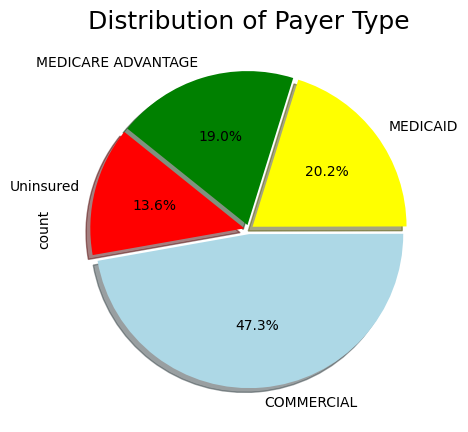

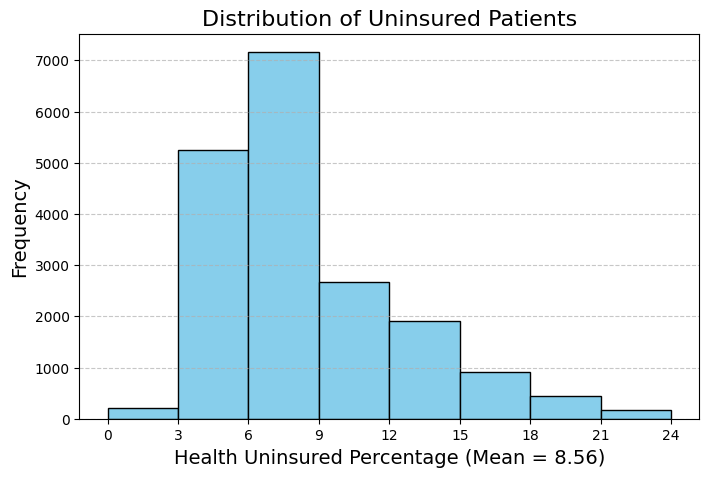

In [53]:
payer_counts = combine['payer_type'].value_counts()

plt.figure(figsize=(10, 5))
plt.title("Distribution of Payer Type", fontsize=18)
payer_counts.plot(kind='pie',
                  autopct='%.1f%%',
                  shadow=True,
                  explode=[0.03]*len(payer_counts),
                  colors=['lightblue', 'yellow', 'green', 'red'],
                  startangle=190)
plt.show()

health_uninsured_mean = combine['health_uninsured'].mean()

plt.figure(figsize=(8, 5))
plt.hist(combine['health_uninsured'], 
         bins=list(range(0,25,3)), 
         edgecolor='black', 
         color='skyblue')
plt.title("Distribution of Uninsured Patients", fontsize=16)
plt.xlabel(f"Health Uninsured Percentage (Mean = {health_uninsured_mean:.2f})", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.xticks(list(range(0,25,3)))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
code_counts = combine['metastatic_cancer_diagnosis_code'].value_counts().head(10)
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=code_counts.values, y=code_counts.index, palette='viridis')
for i, v in enumerate(code_counts.values):
    ax.text(v + 0.2, i, str(v), color='black', va='center')

plt.title('Top 10 Metastatic Cancer Codes')
plt.xlabel('Count')
plt.ylabel('Metastatic Cancer Code')
plt.show()

In [ ]:
code_counts = combine['breast_cancer_diagnosis_code'].value_counts().head(10)
plt.figure(figsize=(12, 7))
ax = sns.barplot(x=code_counts.values, y=code_counts.index, palette='viridis')
for i, v in enumerate(code_counts.values):
    ax.text(v + 0.2, i, str(v), color='black', va='center')

plt.title('Top 10 Breast Cancer Codes')
plt.xlabel('Count')
plt.ylabel('Breast Cancer Code')
plt.show()

In [ ]:
# Define the bin edges
bin_edges = [0, 5, 10, 15, 20, 25, 30, 35, 40]

# Group the data by poverty bins and calculate the mean metastatic diagnosis period for each group
combine['poverty_bin'] = pd.cut(combine['poverty'], bins=bin_edges, right=False)
grouped_df = combine.groupby('poverty_bin')['metastatic_diagnosis_period'].mean().reset_index()

# Plot the histogram
plt.figure(figsize=(10, 6))
sns.barplot(data=grouped_df, x='poverty_bin', y='metastatic_diagnosis_period', palette='Spectral_r')
plt.title('Mean Metastatic Diagnosis Period by Poverty%')
plt.xlabel('Percentage of Poverty in Locality')
plt.ylabel('Mean Metastatic Diagnosis Period')
plt.show()

In [ ]:
# Ensure we cover any indirect operations that might use 'observed'
grouped_data = train.groupby('metastatic_diagnosis_period_segmented', observed=False)

# Histogram of patient_age
plt.figure(figsize=(10, 6))
sns.histplot(data=train, x='patient_age', kde=True, hue='metastatic_diagnosis_period_segmented', bins=10)

plt.title('Distribution of Patient Age')
plt.xlabel('Patient Age')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Assign meaningful labels to the bins for 'Education College or Above'
education_labels = ['No College Education', 'Some College Education', 'Associate\'s Degree', 'Bachelor\'s Degree', 'Advanced Degree']

# Create bins for 'Education College or Above' with meaningful labels
combine['education_college_or_above_bins'] = pd.cut(combine['education_college_or_above'], bins=5, labels=education_labels)

plt.figure(figsize=(12, 8))
sns.barplot(x='education_college_or_above_bins', y='metastatic_diagnosis_period', data=combine)
plt.title('Education Level vs. Metastatic Diagnosis Period')
plt.xlabel('Education College or Above (Binned)')
plt.ylabel('Metastatic Diagnosis Period')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

In [ ]:
#Scatter Plot - Age Median vs. Metastatic Diagnosis Period

plt.figure(figsize=(12, 8))
sns.scatterplot(x='age_median', y='metastatic_diagnosis_period', data=combine)
plt.title('Age Median vs. Metastatic Diagnosis Period')
plt.xlabel('Age Median')
plt.ylabel('Metastatic Diagnosis Period')
plt.show()

# Model Building

In [72]:

#define dependent and independent varibles of train dataset

#X_train =train.drop(['metastatic_diagnosis_period'], axis=1)
X_train =train.drop(columns=["metastatic_diagnosis_period"], axis=1)

#test.drop(columns=["patient_id"], axis=1)

#X_train[columns] = X_train[columns].astype('category')
#test[columns] = test[columns].astype('category')


In [74]:
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 22+36-2370, mixed mode, sharing)
  Starting server from C:\Users\ayaan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\ayaan\AppData\Local\Temp\tmpnx65jwqr
  JVM stdout: C:\Users\ayaan\AppData\Local\Temp\tmpnx65jwqr\h2o_ayaan_started_from_python.out
  JVM stderr: C:\Users\ayaan\AppData\Local\Temp\tmpnx65jwqr\h2o_ayaan_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Asia/Kolkata
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.2
H2O_cluster_version_age:,1 month and 12 days
H2O_cluster_name:,H2O_from_python_ayaan_v85rua
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.915 Gb
H2O_cluster_total_cores:,24
H2O_cluster_allowed_cores:,24
H2O_cluster_status:,"locked, healthy"


In [75]:
train_data = h2o.H2OFrame(train)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [76]:
test_data = h2o.H2OFrame(test)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [77]:
aml = H2OAutoML(max_models=15,seed=42)
aml.train(y='metastatic_diagnosis_period', training_frame=train_data)

AutoML progress: |
00:51:53.994: AutoML: XGBoost is not available; skipping it.

███████████████████████████████████████████████████████████████| (done) 100%


key,value
Stacking strategy,cross_validation
Number of base models (used / total),11/15
# GBM base models (used / total),6/8
# GLM base models (used / total),1/1
# DeepLearning base models (used / total),4/4
# DRF base models (used / total),0/2
Metalearner algorithm,GLM
Metalearner fold assignment scheme,Random
Metalearner nfolds,5
Metalearner fold_column,None


In [78]:
aml1 = H2OAutoML(max_runtime_secs=890,seed=42)
aml1.train(y='metastatic_diagnosis_period', training_frame=train_data)

AutoML progress: |
01:03:05.702: AutoML: XGBoost is not available; skipping it.

███████████████████████████████████████████████████████████████| (done) 100%


key,value
Stacking strategy,cross_validation
Number of base models (used / total),13/58
# GBM base models (used / total),12/51
# GLM base models (used / total),0/1
# DRF base models (used / total),0/2
# DeepLearning base models (used / total),1/4
Metalearner algorithm,GLM
Metalearner fold assignment scheme,Random
Metalearner nfolds,5
Metalearner fold_column,None


In [79]:
leaderboard = aml.leaderboard
print(leaderboard)

model_id                                                   rmse      mse      mae      rmsle    mean_residual_deviance
StackedEnsemble_AllModels_1_AutoML_1_20240626_05153     92.8922  8628.96  73.296     2.26489                   8628.96
StackedEnsemble_BestOfFamily_1_AutoML_1_20240626_05153  93.2302  8691.87  73.6014    2.26908                   8691.87
GBM_5_AutoML_1_20240626_05153                           93.3671  8717.41  73.7268  nan                         8717.41
GBM_1_AutoML_1_20240626_05153                           93.438   8730.67  73.7471    2.26464                   8730.67
GBM_2_AutoML_1_20240626_05153                           93.4699  8736.62  73.3959  nan                         8736.62
GBM_grid_1_AutoML_1_20240626_05153_model_1              93.6681  8773.71  73.506   nan                         8773.71
GBM_3_AutoML_1_20240626_05153                           93.7681  8792.46  73.4728  nan                         8792.46
GBM_4_AutoML_1_20240626_05153                   

In [80]:
best_model = aml.leader
print(best_model)

Model Details
H2OStackedEnsembleEstimator : Stacked Ensemble
Model Key: StackedEnsemble_AllModels_1_AutoML_1_20240626_05153


Model Summary for Stacked Ensemble: 
key                                        value
-----------------------------------------  ----------------
Stacking strategy                          cross_validation
Number of base models (used / total)       11/15
# GBM base models (used / total)           6/8
# GLM base models (used / total)           1/1
# DeepLearning base models (used / total)  4/4
# DRF base models (used / total)           0/2
Metalearner algorithm                      GLM
Metalearner fold assignment scheme         Random
Metalearner nfolds                         5
Metalearner fold_column
Custom metalearner hyperparameters         None

ModelMetricsRegressionGLM: stackedensemble
** Reported on train data. **

MSE: 6646.831997862884
RMSE: 81.52810557018287
MAE: 64.40858647712591
RMSLE: 2.176479540655351
Mean Residual Deviance: 6646.831997862884
R^2: 

In [81]:
best_model1 = aml1.leader
print(best_model1)

Model Details
H2OStackedEnsembleEstimator : Stacked Ensemble
Model Key: StackedEnsemble_AllModels_3_AutoML_2_20240626_10305


Model Summary for Stacked Ensemble: 
key                                        value
-----------------------------------------  ----------------
Stacking strategy                          cross_validation
Number of base models (used / total)       13/58
# GBM base models (used / total)           12/51
# GLM base models (used / total)           0/1
# DRF base models (used / total)           0/2
# DeepLearning base models (used / total)  1/4
Metalearner algorithm                      GLM
Metalearner fold assignment scheme         Random
Metalearner nfolds                         5
Metalearner fold_column
Custom metalearner hyperparameters         None

ModelMetricsRegressionGLM: stackedensemble
** Reported on train data. **

MSE: 6984.813800456813
RMSE: 83.57519847692144
MAE: 65.51440480525956
RMSLE: 2.175975159122673
Mean Residual Deviance: 6984.813800456813
R^2

In [82]:
predictions = best_model.predict(test_data)
predictions_df = predictions.as_data_frame()
predictions1 = best_model1.predict(test_data)
predictions_df1 = predictions1.as_data_frame()

stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


In [83]:
soln['metastatic_diagnosis_period'] =predictions(predictions_df['predict'].values)*1.0+(predictions_df1['predict'].values)*0.0

TypeError: 'H2OFrame' object is not callable

In [ ]:
soln.head()

In [ ]:
#soln.to_csv('submission23.csv', index=False)

In [ ]:
print(soln.isna().sum())